In [1]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [39]:
import pandas as pd
df = pd.read_csv("/content/laptop_pricing_dataset_base.csv",header=None)
df.columns = ["Manufacturer", "Category", "Screen", "GPU", "OS", "CPU_core", "Screen_Size_cm", "CPU_frequency", "RAM_GB", "Storage_GB_SSD", "Weight_kg", "Price"]
df.head()

,Manufacturer,Category,Screen,GPU,OS,CPU_core,Screen_Size_cm,CPU_frequency,RAM_GB,Storage_GB_SSD,Weight_kg,Price
0,Acer,4,IPS Panel,2,1,5,35.56,1.6,8,256,1.6,978
1,Dell,3,Full HD,1,1,3,39.624,2.0,4,256,2.2,634
2,Dell,3,Full HD,1,1,7,39.624,2.7,8,256,2.2,946
3,Dell,4,IPS Panel,2,1,5,33.782,1.6,8,128,1.22,1244
4,HP,4,Full HD,2,1,7,39.624,1.8,8,256,1.91,837


In [40]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Manufacturer      0
Category          0
Screen            0
GPU               0
OS                0
CPU_core          0
Screen_Size_cm    0
CPU_frequency     0
RAM_GB            0
Storage_GB_SSD    0
Weight_kg         0
Price             0
dtype: int64


In [41]:
df = df.drop_duplicates()

In [42]:
encoder = LabelEncoder()
for column in df.select_dtypes(include='object').columns:
    df[column] = encoder.fit_transform(df[column].astype(str))

In [43]:
df = df.dropna()

In [44]:
print(df.columns)

Index(['Manufacturer', 'Category', 'Screen', 'GPU', 'OS', 'CPU_core',
       'Screen_Size_cm', 'CPU_frequency', 'RAM_GB', 'Storage_GB_SSD',
       'Weight_kg', 'Price'],
      dtype='object')


In [46]:
X = df.drop("Price", axis=1)
y = df["Price"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [48]:
model = LinearRegression()

In [49]:
model.fit(X_train, y_train)

LinearRegression()

In [50]:
y_pred = model.predict(X_test)

In [51]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [52]:
result = pd.DataFrame({
"Actual Price": y_test.values,
"Predicted Price": y_pred
})
print("\nActual vs Predicted:")
print(result.head(10))


Actual vs Predicted:
   Actual Price  Predicted Price
0          1498      1724.510145
1           876      1482.602745
2          1188      1925.831601
3          1142      1429.369350
4          1117      1324.645356
5           888      1173.068528
6          1068      1388.951444
7          1219      1506.608618
8           710       640.836192
9          1119      1182.721424


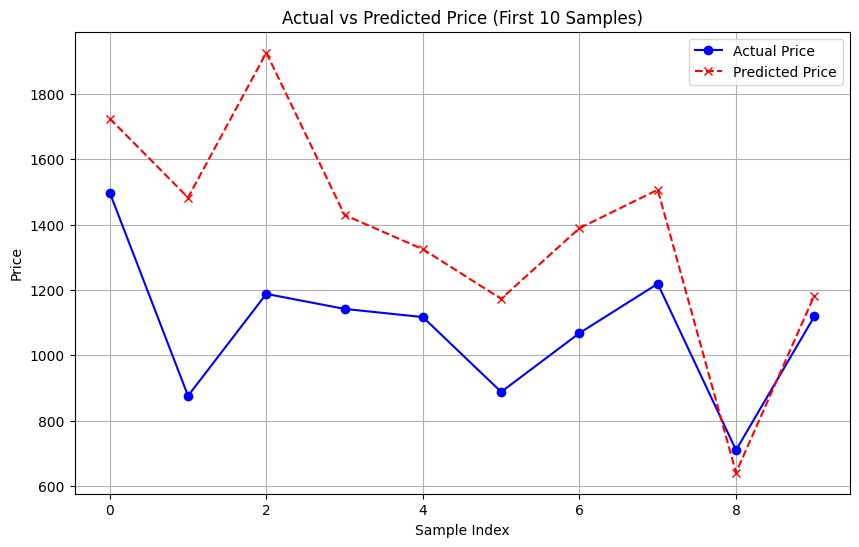

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(result["Actual Price"].head(10).values, label="Actual Price", marker='o', color='blue')
plt.plot(result["Predicted Price"].head(10).values, label="Predicted Price", marker='x', color='red', linestyle='--')
plt.title("Actual vs Predicted Price (First 10 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

In [54]:
print("Actual vs Predicted:")
print(result.head(10))
print("\nModel Execution Completed Successfully!")

Actual vs Predicted:
   Actual Price  Predicted Price
0          1498      1724.510145
1           876      1482.602745
2          1188      1925.831601
3          1142      1429.369350
4          1117      1324.645356
5           888      1173.068528
6          1068      1388.951444
7          1219      1506.608618
8           710       640.836192
9          1119      1182.721424

Model Execution Completed Successfully!
